In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip uninstall -y -q torchao
%pip install -q "diffusers==0.39.0" "peft==0.19.1" transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 19.1 MB/s eta 0:00:00


In [ ]:
import diffusers
import peft
import torch

print('PyTorch:', torch.__version__)
print('Diffusers:', diffusers.__version__)
print('PEFT:', peft.__version__)
print('GPU:', torch.cuda.get_device_name(0))

assert diffusers.__version__ == '0.39.0'
assert peft.__version__ == '0.19.1'
assert torch.cuda.is_available(), 'A GPU runtime is required.'

PyTorch: 2.11.0+cu128
Diffusers: 0.39.0
PEFT: 0.19.1
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from pathlib import Path

MODEL_NAME = 'stabilityai/stable-diffusion-xl-base-1.0'
VAE_NAME = 'madebyollin/sdxl-vae-fp16-fix'

RUN_DIR = Path(
    '/content/drive/MyDrive/bachelor_thesis_data/diffusion/'
    'sdxl_melanoma_lora_run1'
)
CHECKPOINT_DIR = RUN_DIR / 'checkpoint-2000'
LORA_FILE = CHECKPOINT_DIR / 'pytorch_lora_weights.safetensors'
GENERATED_DIR = RUN_DIR / 'generated_checkpoint_2000'
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

assert RUN_DIR.is_dir(), f'Run directory missing: {RUN_DIR}'
assert CHECKPOINT_DIR.is_dir(), f'Checkpoint missing: {CHECKPOINT_DIR}'
assert LORA_FILE.is_file(), f'LoRA weights missing: {LORA_FILE}'

GENERATION_PROMPT = (
    'a high quality dermoscopic photograph of sks melanoma, '
    'centered pigmented skin lesion'
)
NEGATIVE_PROMPT = (
    'clinical photograph, body, face, multiple lesions, text, watermark, '
    'diagram, illustration, blurry, low quality, distorted'
)
FIRST_SEED = 0
BATCH_SIZE = 8
INFERENCE_STEPS = 40
GUIDANCE_SCALE = 7.0

print('Checkpoint:', CHECKPOINT_DIR)
print('Generated images:', GENERATED_DIR)

Checkpoint: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/checkpoint-2000
Generated images: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/generated_checkpoint_2000


In [ ]:
from diffusers import AutoencoderKL, DiffusionPipeline

torch.backends.cuda.matmul.allow_tf32 = True

vae = AutoencoderKL.from_pretrained(
    VAE_NAME,
    torch_dtype=torch.float16,
)

pipe = DiffusionPipeline.from_pretrained(
    MODEL_NAME,
    vae=vae,
    torch_dtype=torch.float16,
    variant='fp16',
    use_safetensors=True,
).to('cuda')

pipe.load_lora_weights(
    str(CHECKPOINT_DIR),
    weight_name='pytorch_lora_weights.safetensors',
)
pipe.enable_vae_slicing()
pipe.set_progress_bar_config(disable=True)

print('Checkpoint 2000 loaded successfully.')

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Checkpoint 2000 loaded successfully.


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2273: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [ ]:
from tqdm.auto import tqdm

def image_path(index):
    return GENERATED_DIR / f'diffusion_melanoma_{index:05d}.png'

def generate_images(total_images):
    assert 1 <= total_images <= 7000

    missing_indices = [
        index for index in range(total_images)
        if not image_path(index).is_file()
    ]

    print('Requested:', total_images)
    print('Already generated:', total_images - len(missing_indices))
    print('Remaining:', len(missing_indices))

    for start in tqdm(range(0, len(missing_indices), BATCH_SIZE)):
        batch_indices = missing_indices[start:start + BATCH_SIZE]
        batch_seeds = [FIRST_SEED + index for index in batch_indices]

        generators = [
            torch.Generator(device='cuda').manual_seed(seed)
            for seed in batch_seeds
        ]

        with torch.inference_mode():
            images = pipe(
                prompt=[GENERATION_PROMPT] * len(batch_indices),
                negative_prompt=[NEGATIVE_PROMPT] * len(batch_indices),
                height=512,
                width=512,
                num_inference_steps=INFERENCE_STEPS,
                guidance_scale=GUIDANCE_SCALE,
                generator=generators,
            ).images

        for index, image in zip(batch_indices, images):
            image.save(image_path(index))

    completed = sum(image_path(i).is_file() for i in range(total_images))
    assert completed == total_images
    print(f'Complete: {completed}/{total_images}')

In [ ]:
generate_images(total_images=64)

Requested: 64
Already generated: 0
Remaining: 64


  0%|          | 0/8 [00:00<?, ?it/s]

Complete: 64/64


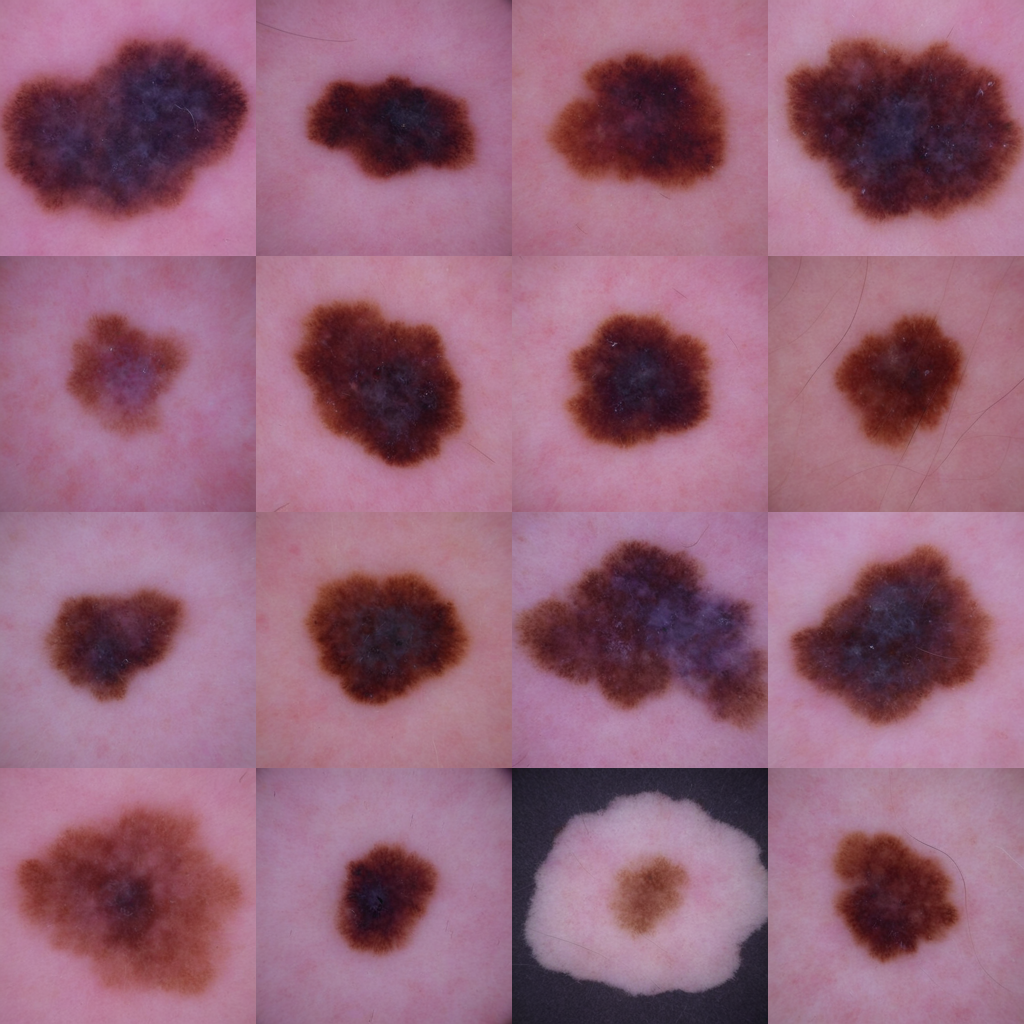

Pilot grid: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/generated_checkpoint_2000/pilot_grid_first_16.png


In [ ]:
from PIL import Image
from IPython.display import display

sample_paths = [image_path(index) for index in range(16)]
assert all(path.is_file() for path in sample_paths)

tile_size = 256
columns = 4
rows = 4
grid = Image.new('RGB', (columns * tile_size, rows * tile_size), 'white')

for index, path in enumerate(sample_paths):
    with Image.open(path) as source_image:
        tile = source_image.convert('RGB').resize((tile_size, tile_size))
    x = (index % columns) * tile_size
    y = (index // columns) * tile_size
    grid.paste(tile, (x, y))

PILOT_GRID_PATH = GENERATED_DIR / 'pilot_grid_first_16.png'
grid.save(PILOT_GRID_PATH)
display(grid)
print('Pilot grid:', PILOT_GRID_PATH)

In [ ]:
from pathlib import Path
from PIL import Image
from IPython.display import display
import torch

CFG5_PILOT_DIR = RUN_DIR / "pilot_checkpoint_2000_g5"
CFG5_PILOT_DIR.mkdir(parents=True, exist_ok=True)

PILOT_SIZE = 16

for start in range(0, PILOT_SIZE, BATCH_SIZE):
    batch_indices = list(
        range(start, min(start + BATCH_SIZE, PILOT_SIZE))
    )

    batch_seeds = [
        FIRST_SEED + index for index in batch_indices
    ]

    generators = [
        torch.Generator(device="cuda").manual_seed(seed)
        for seed in batch_seeds
    ]

    with torch.inference_mode():
        images = pipe(
            prompt=[GENERATION_PROMPT] * len(batch_indices),
            negative_prompt=[NEGATIVE_PROMPT] * len(batch_indices),
            height=512,
            width=512,
            num_inference_steps=40,
            guidance_scale=5.0,
            generator=generators,
        ).images

    for index, image in zip(batch_indices, images):
        image.save(
            CFG5_PILOT_DIR / f"cfg5_seed_{FIRST_SEED + index}.png"
        )

print("Guidance-5 pilot generated.")

Guidance-5 pilot generated.


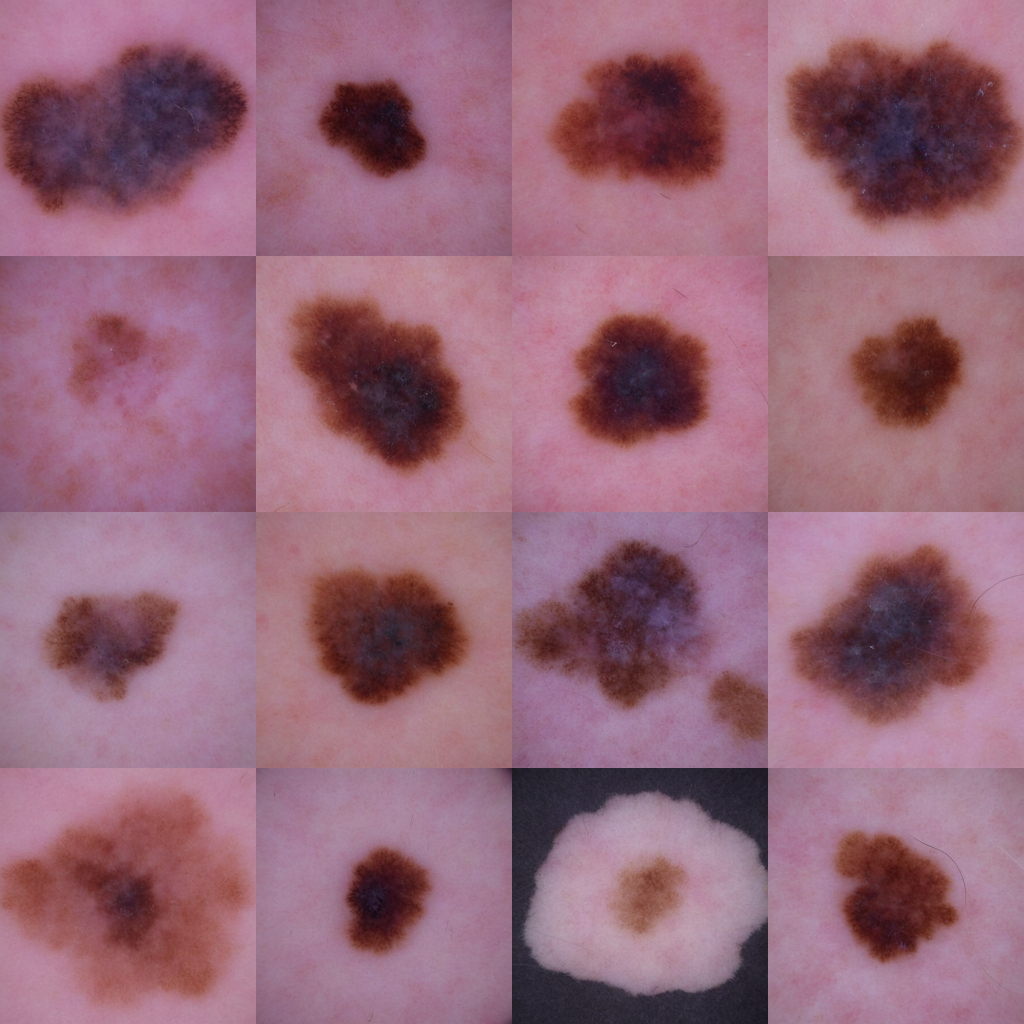

Saved: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/pilot_checkpoint_2000_g5/pilot_grid_cfg5.png


In [ ]:
tile_size = 256
columns = 4
rows = 4

grid_cfg5 = Image.new(
    "RGB",
    (columns * tile_size, rows * tile_size),
    "white"
)

for index in range(PILOT_SIZE):
    path = (
        CFG5_PILOT_DIR /
        f"cfg5_seed_{FIRST_SEED + index}.png"
    )

    with Image.open(path) as image:
        tile = image.convert("RGB").resize(
            (tile_size, tile_size)
        )

    x = (index % columns) * tile_size
    y = (index // columns) * tile_size
    grid_cfg5.paste(tile, (x, y))

display(grid_cfg5)

CFG5_GRID_PATH = CFG5_PILOT_DIR / "pilot_grid_cfg5.png"
grid_cfg5.save(CFG5_GRID_PATH)

print("Saved:", CFG5_GRID_PATH)

In [ ]:
generate_images(total_images=7000)

Requested: 7000
Already generated: 64
Remaining: 6936


  0%|          | 0/867 [00:00<?, ?it/s]

Complete: 7000/7000


In [ ]:
import csv
import json
from PIL import Image

expected_paths = [image_path(index) for index in range(6000)]
missing = [path for path in expected_paths if not path.is_file()]
assert not missing, f'Missing {len(missing)} generated images.'

for path in tqdm(expected_paths, desc='Verifying files'):
    with Image.open(path) as image:
        image.verify()
    with Image.open(path) as image:
        assert image.size == (512, 512), f'Wrong size: {path}'

metadata_path = GENERATED_DIR / 'generation_metadata.csv'
with metadata_path.open('w', newline='') as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=['filename', 'index', 'seed', 'in_first_943_subset'],
    )
    writer.writeheader()
    for index, path in enumerate(expected_paths):
        writer.writerow({
            'filename': path.name,
            'index': index,
            'seed': FIRST_SEED + index,
            'in_first_943_subset': index < 943,
        })

config = {
    'base_model': MODEL_NAME,
    'vae': VAE_NAME,
    'lora_checkpoint': 'checkpoint-2000',
    'checkpoint_training_steps': 2000,
    'prompt': GENERATION_PROMPT,
    'negative_prompt': NEGATIVE_PROMPT,
    'resolution': [512, 512],
    'num_inference_steps': INFERENCE_STEPS,
    'guidance_scale': GUIDANCE_SCALE,
    'first_seed': FIRST_SEED,
    'number_of_images': 6000,
    'doubled_experiment_subset_size': 943,
}
config_path = GENERATED_DIR / 'generation_config.json'
config_path.write_text(json.dumps(config, indent=2))

print('Verified generated images:', len(expected_paths))
print('Doubled subset: indices 0–942 (943 images)')
print('Full synthetic set: indices 0–5999 (6,000 images)')
print('Metadata:', metadata_path)
print('Configuration:', config_path)